# California Housing






In [ ]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Access the features (X) and target (y)
df = housing.frame
print(df.head())
print(df.tail())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


1. controllare che min e max abbiano senso (AveRooms e anche AveOccup con min e max fuori scala)
2. rapporto tra media e dev std. Se è maggiore di 1, c'è una forte dispersione di dati su quella colonna (AveOccup e Population)
3. se media e 50% sono simili tra loro, se non lo sono abbiamo una distribuzione chiamata skewed (se media << 50% applico una trasformazione logaritmica per bilanciare)


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


1. Controllare le colonne che hanno dei null
2. Controllare le colonne che non sono numeri, perchè la matematica non sa gestire le stringhe


## gestione valori nulli

- se nulli < 5% rimuovo righe nulle
- se nulli < 15/20% sostituisco con medie i numeri e moda le stringhe
- se nulli > 20% o elimino colonna o creo un modello di machine learning per predirre i nulli

### sostituzione con media
immaginiamo un dataset con età e guadagno, ho il 10% dei nulli sul guadagno
raggruppo in fasce d' età e faccio la media di ogni fascia, sostituisco i nulli del guadagno in base all' età associata

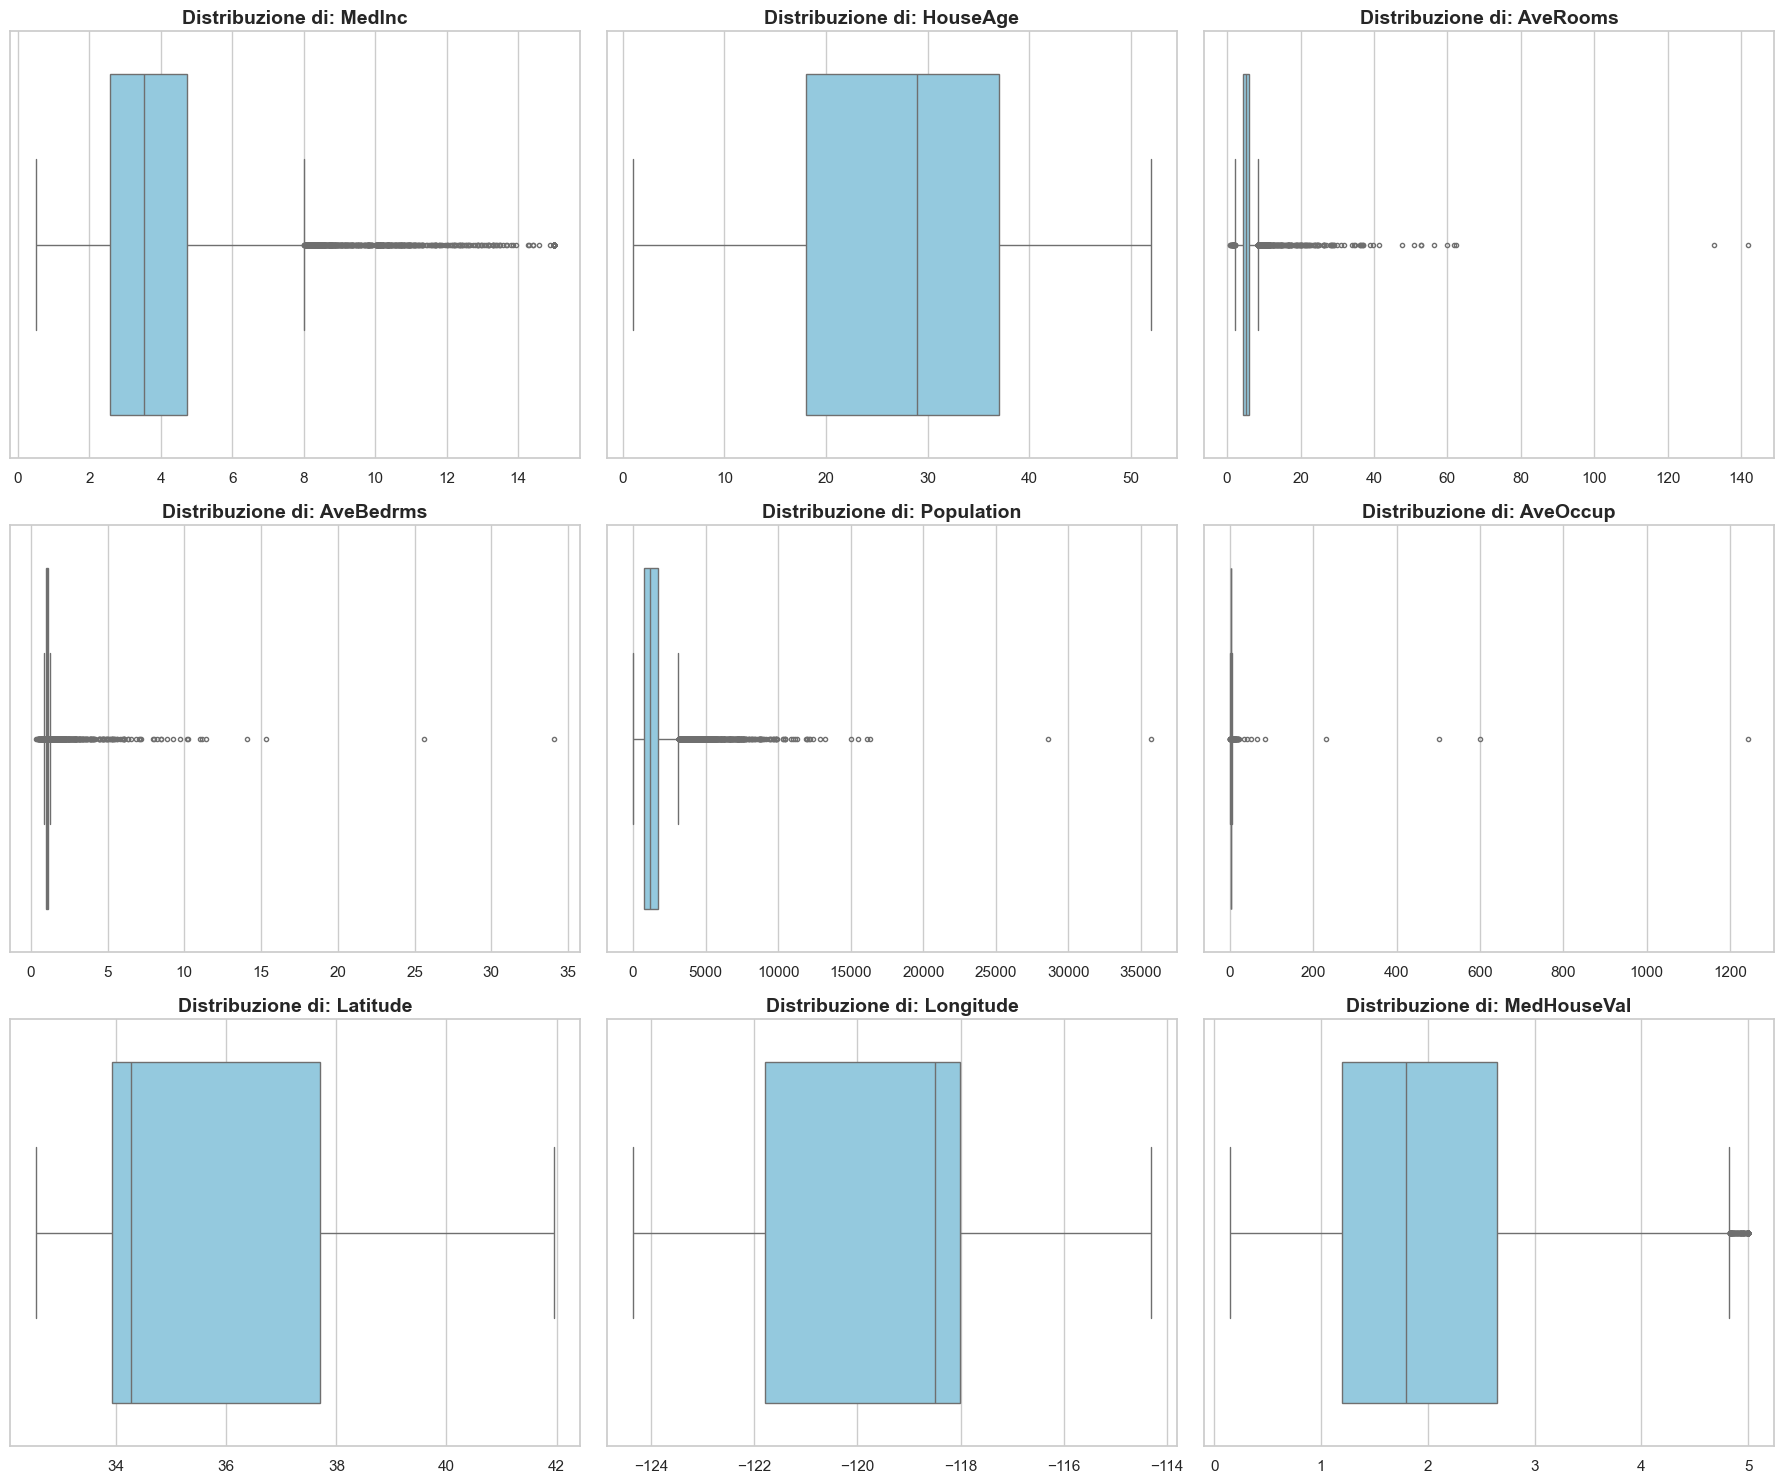

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

### cosa rappresentano le linee verticali del boxplot?
 Le linee verticali rappresentano i valori minimi e massimi (non anomali) dei dati in ogni colonna.

e la parte blu del boxplot?


La parte blu del boxplot rappresenta l'intervallo interquartile (IQR), quindi il 50% centrale dei dati.


La linea all'interno del box rappresenta la mediana.


i pallini sono gli outlier

## outliers
gli outliers possono essere di due tipi:
- caso statisticamente raro (persona alta 2,30m)
- errore di inserimento(persona alta 23m)

## Cosa mi devo chiedere?

- perché ci sono così tanti outliers?
- ci sono degli outlier estremi? Da cosa sono dovuti?

# Se decido di rimuovere gli outlier per pulire il dataset (non sempre vanno puliti gli outlier)

### 1. Metodo IQR (Interquartile Range)

È la tecnica usata dai **boxplot**. Si basa sulla distanza tra il primo quartile ($Q_1$) e il terzo quartile ($Q_3$). 
Tutto ciò che cade fuori dall'intervallo $[Q_1 - 1.5 \times IQR, Q_3 + 1.5 \times IQR]$ viene considerato outlier.

In [ ]:
def remove_outliers_iqr(data, columns):
    df_clean = data.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Filtraggio
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

# Applichiamolo solo ad alcune colonne critiche (es. MedInc e AveRooms)
df_iqr = remove_outliers_iqr(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con IQR: {len(df) - len(df_iqr)}")

Righe rimosse con IQR: 711


### 2. Metodo Z-Score (Deviazione Standard)

Questa tecnica si basa sulla distribuzione normale. Si calcola quanto un valore dista dalla media in termini di deviazioni standard ($\sigma$). La formula dello Z-score è:

$$Z = \frac{x - \mu}{\sigma}$$

Solitamente, un valore con uno **Z-score maggiore di 3 o minore di -3** è considerato un outlier estremo (rappresenta meno dello 0.3% dei dati in una distribuzione normale).

In [ ]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
df_zscore = remove_outliers_zscore(df, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

'import numpy as np\nfrom scipy import stats\n\ndef remove_outliers_zscore(data, columns, threshold=3):\n    df_clean = data.copy()\n    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata\n    z_scores = np.abs(stats.zscore(df_clean[columns]))\n\n    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold\n    filtered_entries = (z_scores < threshold).all(axis=1)\n    return df_clean[filtered_entries]\n\n# Applicazione\ndf_zscore = remove_outliers_zscore(df, [\'MedInc\', \'AveRooms\', \'AveOccup\'])\nprint(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")'

IQR è più aggressivo ma funziona bene anche su distribuzioni più sporche 

Z-SCORE meno aggressivo ma funziona solo su dati distribuiti normalmente

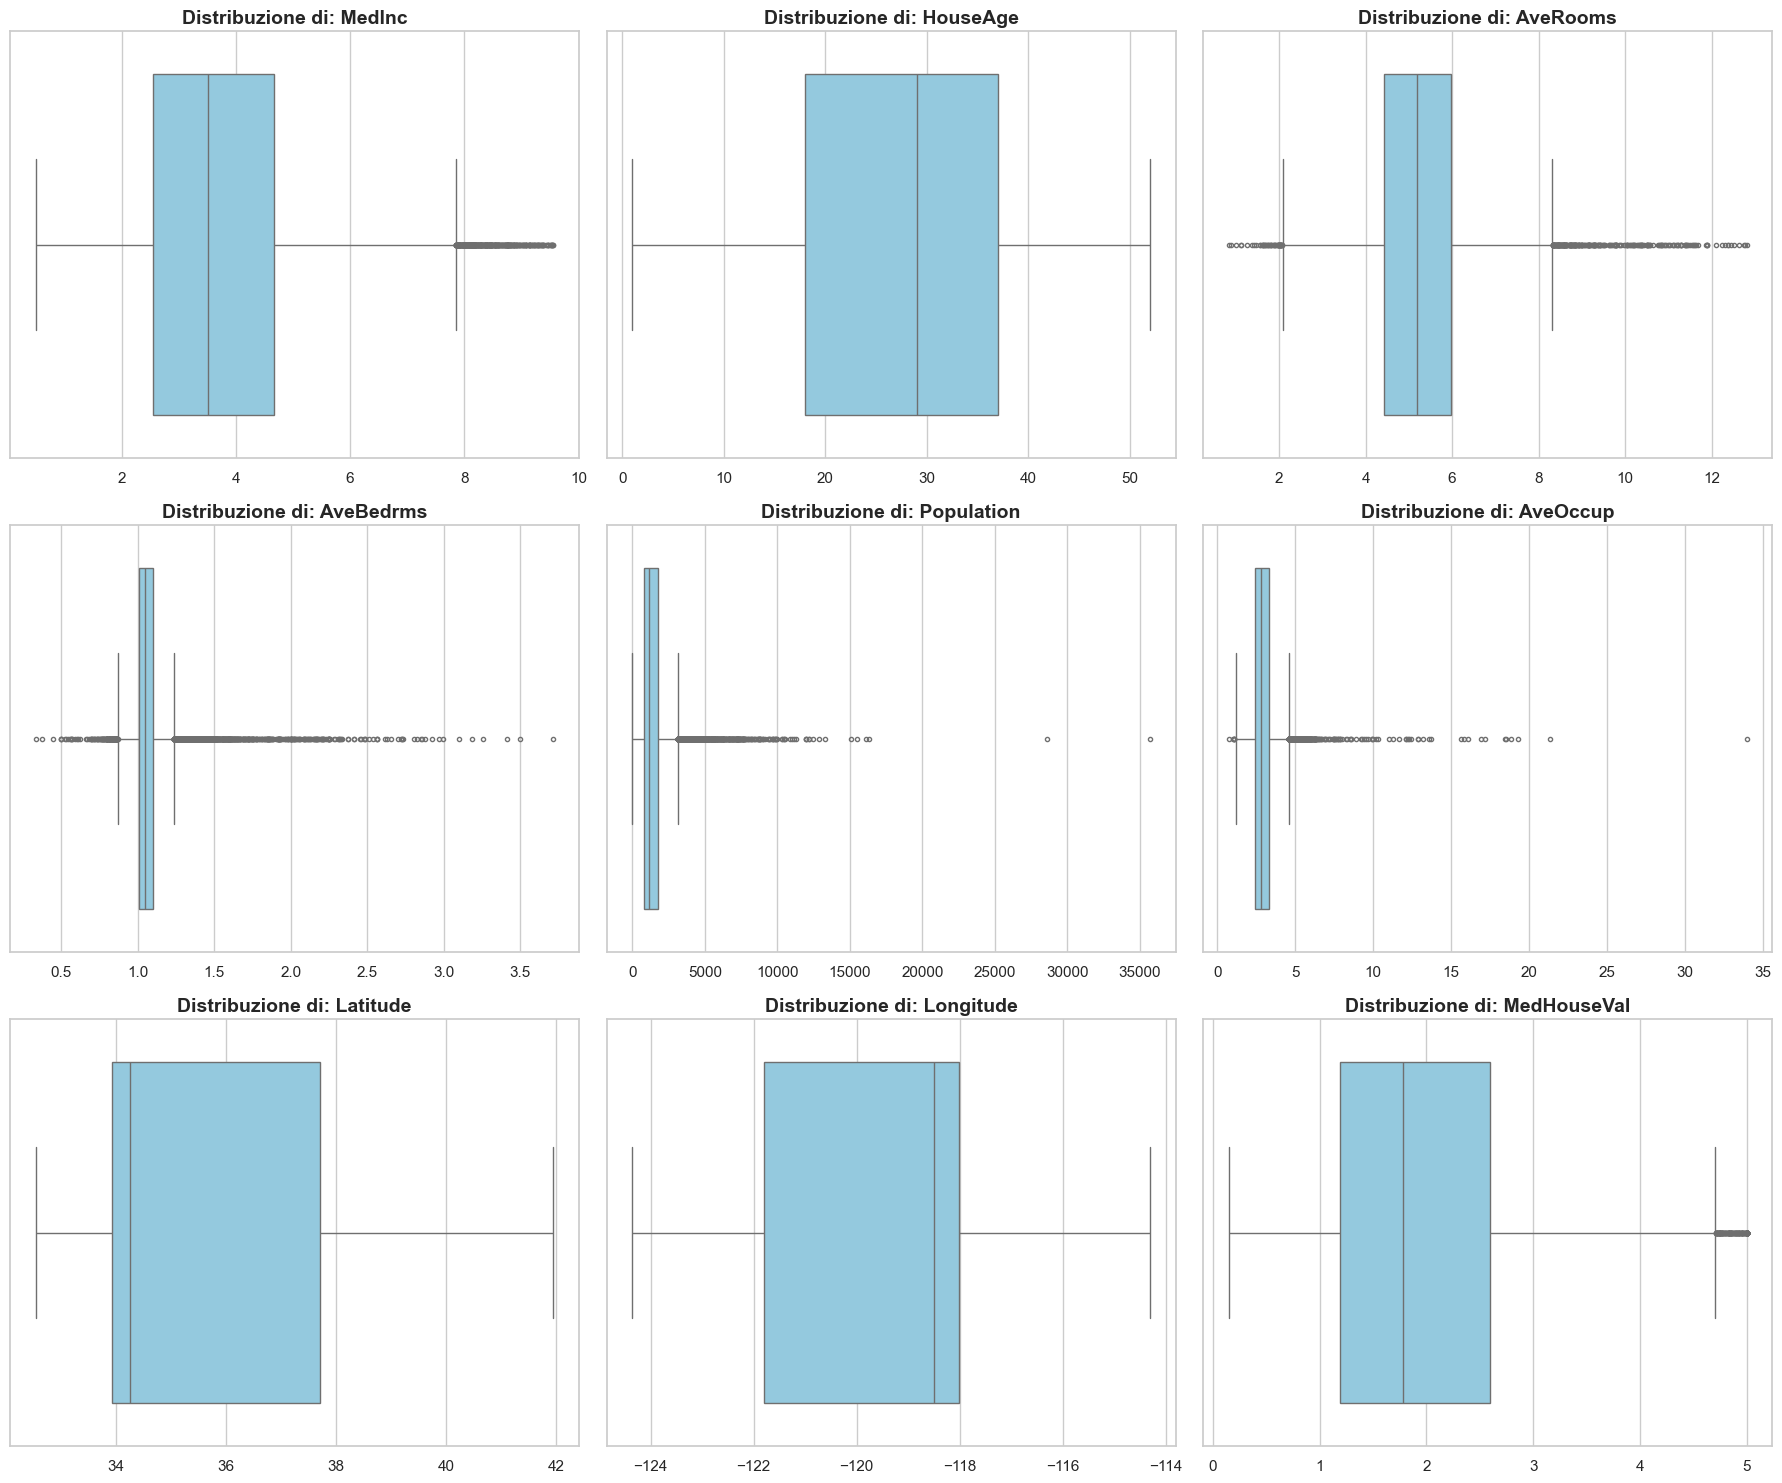

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Impostiamo lo stile e la griglia
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten() # Appiattiamo la matrice di assi per iterare facilmente

# 3. Ciclo per creare un boxplot per ogni colonna
for i, col in enumerate(df_zscore.columns):
    sns.boxplot(x=df_zscore[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('') # Rimuoviamo l'etichetta x per pulizia

# 4. Ottimizzazione del layout
plt.tight_layout()
plt.show()

## colonne categoriche

se la colonna è binaria (si/no, True/False) trasformiamo in 0,1

se ho più variabili (Milano, Roma, Napoli) assegno a ogni variabile un numero (Milano:1, Roma:2, Napoli:3)

ma qui sorge un problema: con la nuova configurazione per il computer Milano + Roma = Napoli, non posso quindi applicarla su variabili scollegate

se avessi piccolo-medio-grande che hanno un rapporto di grandezza potrei farlo ma se sono scollegate devo procedere diversamente

creo una colonna binaria per ogni opzione:

nuova colonna: is_Milano che contiene True o False ossia 0 o 1, is_Roma, is_Napoli (attenzione che se ho 100 opzioni sto aggiungendo 100 dimensioni)

### 1. Label Encoding

Il `LabelEncoder` trasforma le stringhe in numeri progressivi ($0, 1, 2, ...$).

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Esempio: Target con tre classi
y = ['Basso', 'Medio', 'Alto', 'Basso', 'Alto']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classi originali: {le.classes_}")
print(f"Valori trasformati: {y_encoded}")
# Output: [1, 2, 0, 1, 0] (l'ordine è spesso alfabetico)

Classi originali: ['Alto' 'Basso' 'Medio']
Valori trasformati: [1 2 0 1 0]


### 2. One-Hot Encoding

Questa è la tecnica standard per le variabili categoriche senza un ordine intrinseco (es. "Colore", "Città"). Crea una nuova colonna binaria ($0$ o $1$) per ogni categoria.

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# DataFrame di esempio
df_test = pd.DataFrame({'Città': ['Roma', 'Milano', 'Napoli', 'Roma']})

# Inizializziamo l'encoder
# sparse_output=False serve per avere un array NumPy leggibile (non una matrice sparsa)
ohe = OneHotEncoder(sparse_output=False)

# Trasformazione
ohe_transformed = ohe.fit_transform(df_test[['Città']])

# Creiamo un nuovo DataFrame con i nomi delle colonne corretti
df_ohe = pd.DataFrame(ohe_transformed, columns=ohe.get_feature_names_out(['Città']))

print(df_ohe)

   Città_Milano  Città_Napoli  Città_Roma
0           0.0           0.0         1.0
1           1.0           0.0         0.0
2           0.0           1.0         0.0
3           0.0           0.0         1.0


## visualizziamo distribuzioni delle colonne

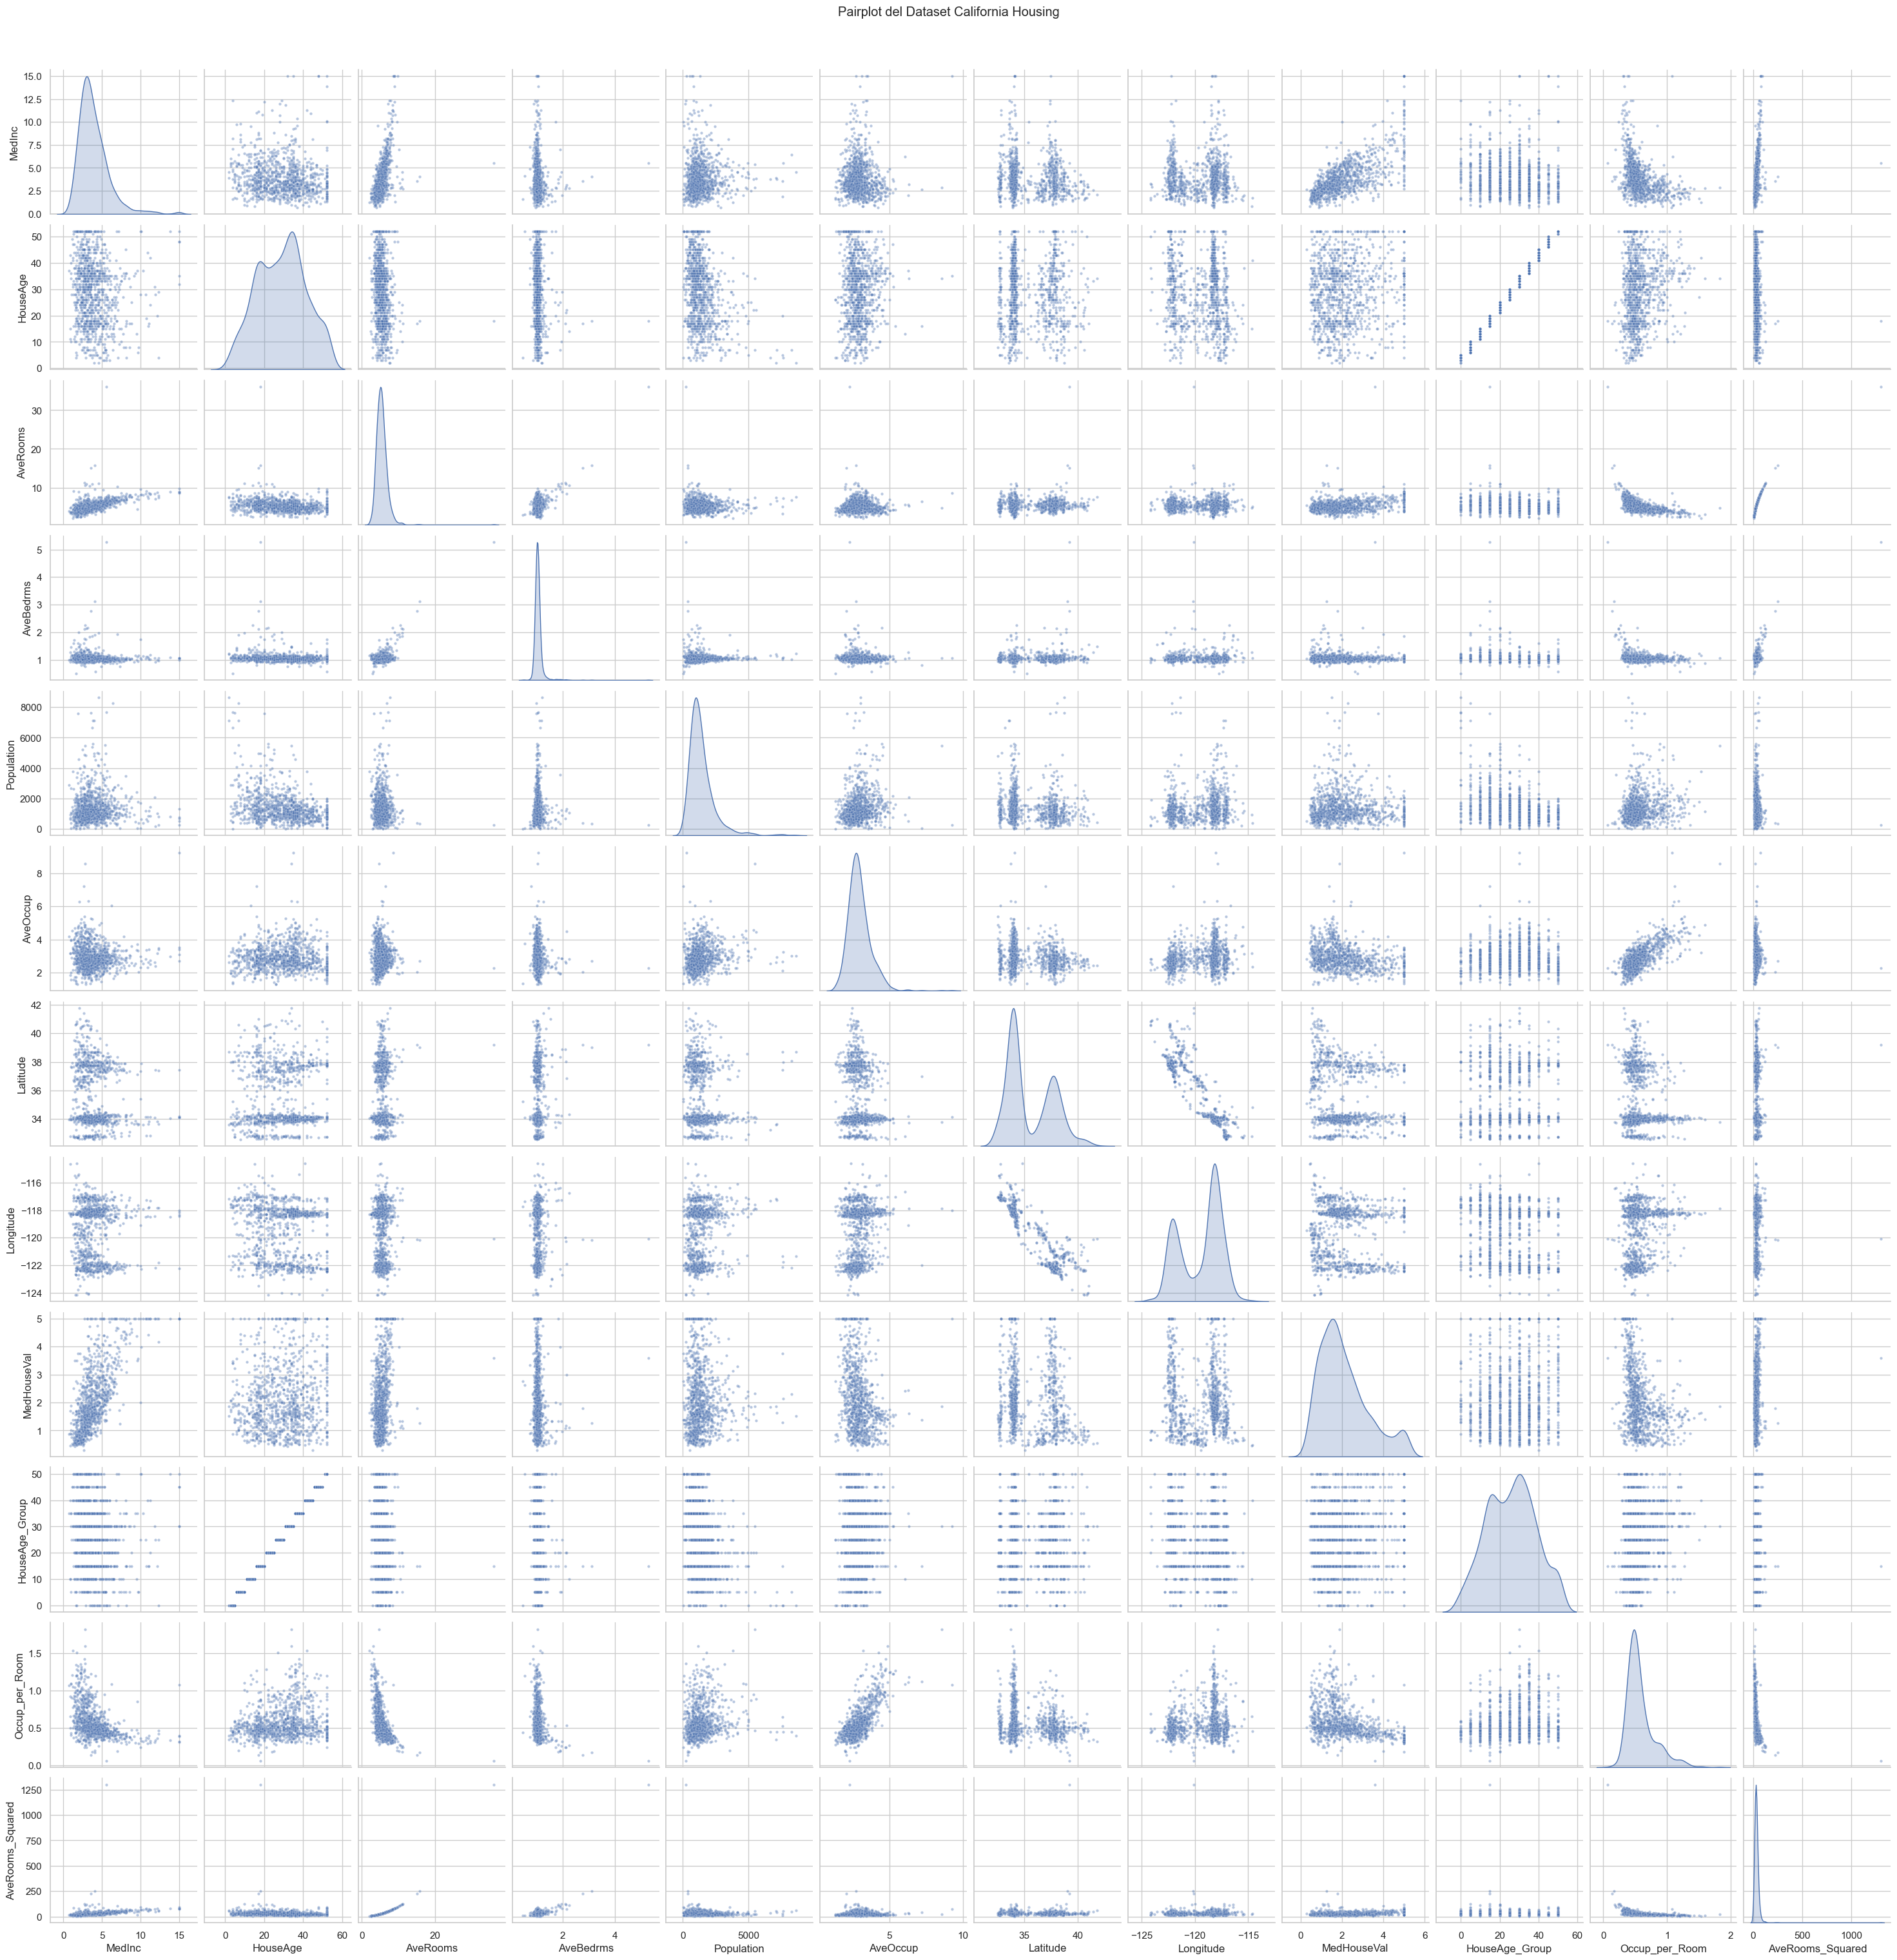

In [ ]:
# Campionamento per velocità e chiarezza (es. 1000 righe)
df_sample = df.sample(n=1000, random_state=42)

# Creazione del Pairplot
# 'diag_kind' imposta i grafici sulla diagonale (istogrammi o densità KDE)
# 'plot_kws' serve per rimpicciolire i punti e renderli trasparenti
sns.pairplot(df_sample, 
             diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Pairplot del Dataset California Housing", y=1.02)
plt.show()

Da questo grafico noto che

- ho delle variabili lineari tra di loro, sopratutto la variabile target medhouseval 
- ho distribuzioni gaussiane, un po skewed (potrei applicare una trasformazione logaritmica)
- i due picchi di longitude e latitude sono dovuti a San Francisco e Los Angeles

## Cosa devo valutare?

- diagonale con le distribuzioni, controllare che siano gaussiane, controllare skewness e controllare le non gaussiane e capire perché non sono gaussiane
- ho distribuzioni incrociate lineari? Ce ne sono di moooolto lineari? Ci sono cap di valore forzato? (come in medHouseVal) Ci sono distribuzioni più curve? 

## Matrice di Correlazione

### Correlazione di Pearson

Ottima per trovare varibili linearmente dipendenti tra di loro, sono interessanti tutte le correalzioni superiori a + 0.15 e inferiori di - 0.15

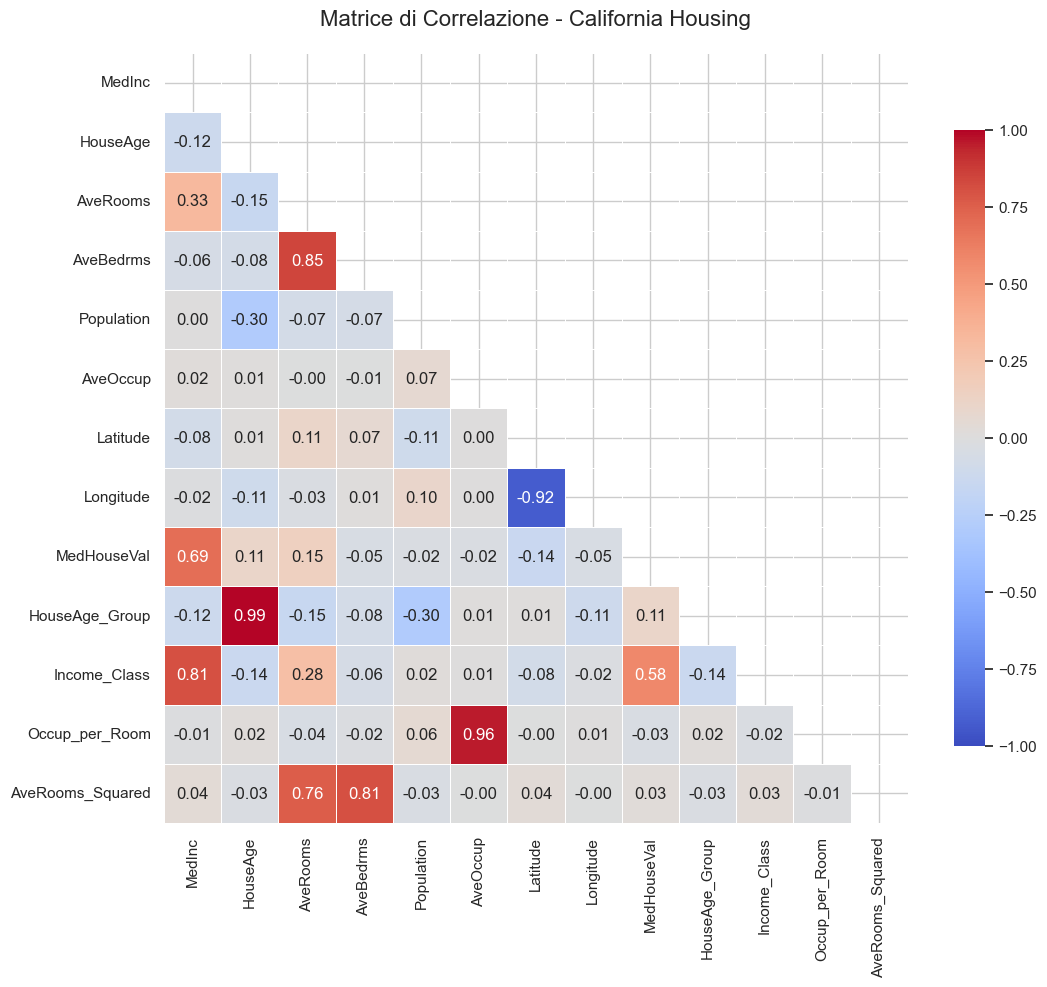

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di correlazione
# Usiamo il metodo di Pearson (default)
corr = df.corr()

# 2. Creazione di una "maschera" per nascondere la parte superiore
# Essendo la matrice speculare, vedere entrambi i lati crea solo confusione visiva
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Configurazione del grafico
plt.figure(figsize=(12, 10))

# Disegniamo la heatmap
sns.heatmap(
    corr, 
    mask=mask,          # Nasconde la parte superiore duplicata
    annot=True,         # Scrive i numeri dentro i quadratini
    fmt=".2f",          # Formatta i numeri a 2 decimali
    cmap='coolwarm',    # Colore: rosso (positivo), blu (negativo), bianco (zero)
    vmin=-1, vmax=1,    # Imposta i limiti della scala colorata
    center=0,           # Il centro della scala è lo zero
    linewidths=.5,      # Aggiunge una linea di separazione tra i quadrati
    cbar_kws={"shrink": .8} # Rimpicciolisce la barra dei colori laterale
)

plt.title('Matrice di Correlazione - California Housing', fontsize=16, pad=20)
plt.show()

## Ma se avessimo variabili non correlate linearmente o con tanti outlier?

Possiamo usare la correlazione di Spearman che si basa sui ranghi

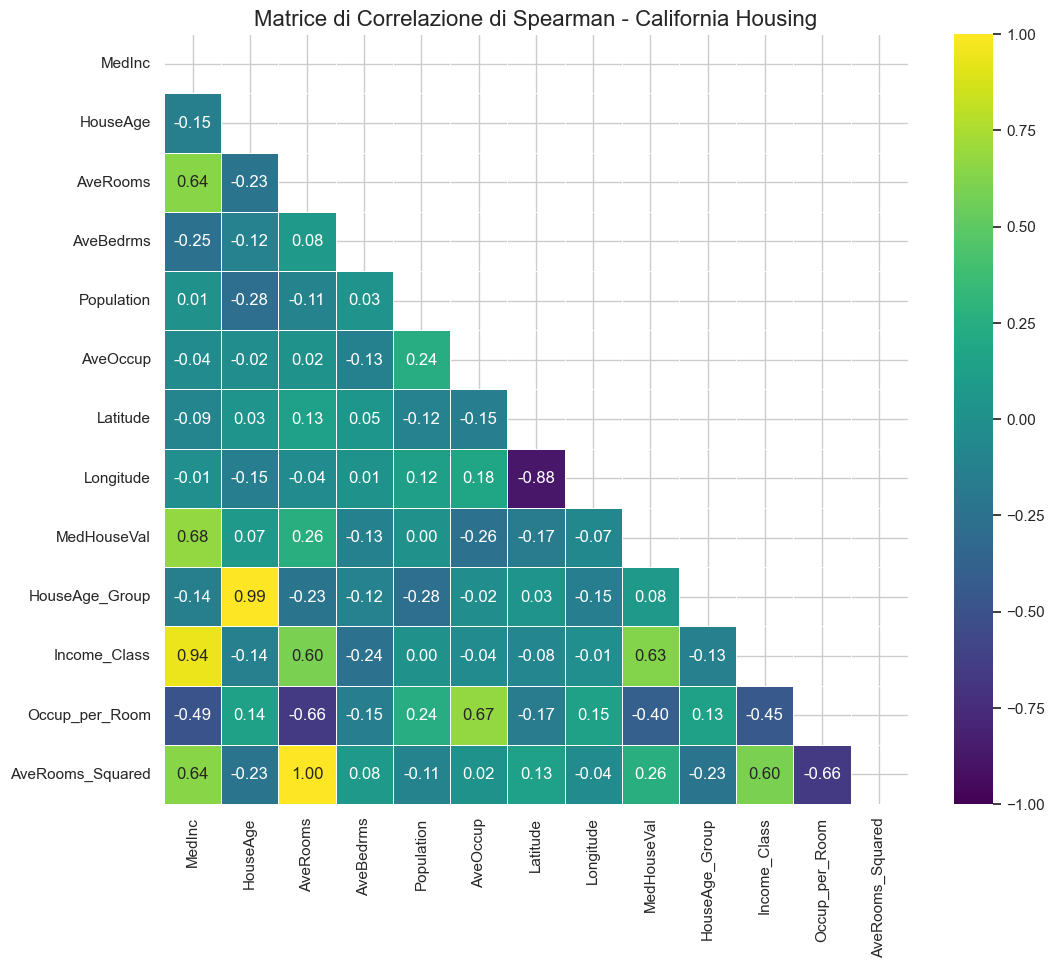

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

## Cosa devo notare?

- ci sono correlazioni fortemente positive o negative?
- hanno senso queste correlazioni? Se m^2 hanno correlazione inversa con il prezzo mi devo fare qualche domanda
- ci sono colonne che ci aspettavamo essere correlate e non lo sono? (mi aspetto che la casa più costi più sia nuova, se la correlazione è 0 o comunque bassa devo capire perché)

## Feature Engineering

Creare nuove feature come combinazioni o modifiche interessanti di feature esistenti:
 - creare raggruppamenti su varibili continue (per house age 1 gruppo ogni 5 anni e vedere se ci sono andamenti o pattern, oppure soglie di valore su medInc per definire ceto basso, medio, ricco e vedere se cambiano alcuni pattern)
 - varibili come divisione di feature esistenti (AveOccup/AveRooms)
 - varibili al quadrato per eventuali relazioni non lineari (da sperman potrei provare a usare ave rooms al quadrato)
 - varibili derivate da consocenza del settore (soprattutto in casi medici, se ho altezza e peso faccio peso/altezza che è un indicatore tecnico medico)

## ATTENZIONE

- di solito le cose più interessanti si ottengono o con raggruppamenti o con divisioni
- raggruppate tutto il possibile e cercate andamenti rispetto alla varibile target (come cambia il prezzo tra case vecchie medie e nuove? Come cambiano le correlazioni interne se seleziono solo le case nuove? Magari ci sono correlazioni che valgono solo per le case nuove e che non potete vedere altrimenti)
- filtrate e stampate tanti grafici in base a categorie che assegnate in base ai raggruppamenti

Correlazione di Spearman con il Target (MedHouseVal):
MedHouseVal         1.000000
Income_Class        0.625628
AveRooms_Squared    0.263367
HouseAge_Group      0.075584
Occup_per_Room     -0.399798
Name: MedHouseVal, dtype: float64


C:\Users\Davec\AppData\Local\Temp\ipykernel_1336\2585107523.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')


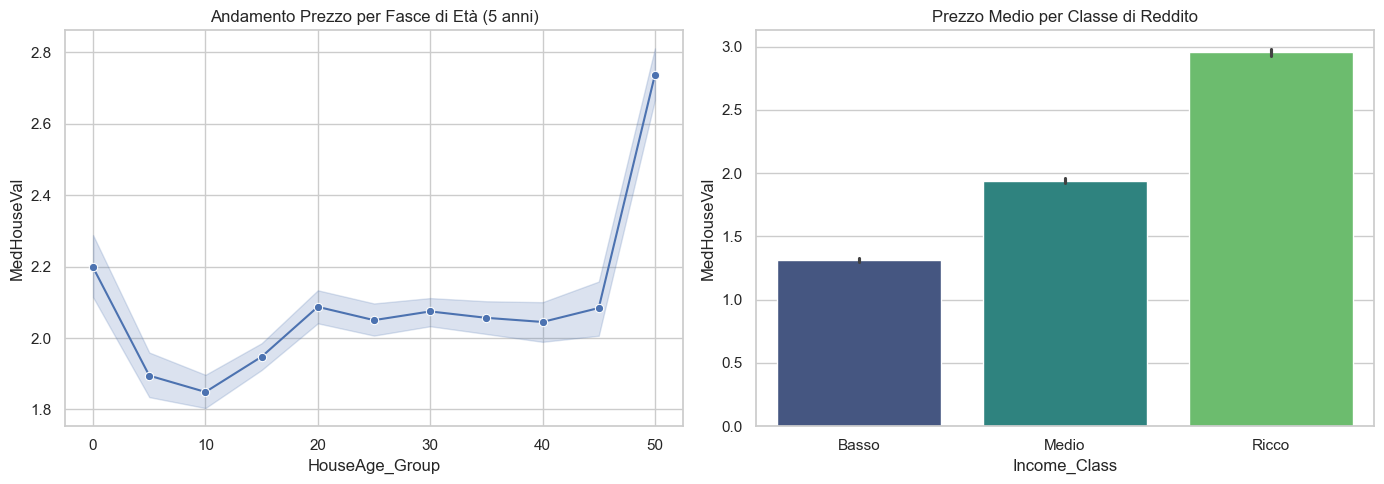

In [ ]:
# --- FEATURE ENGINEERING ---

# A. Raggruppamento HouseAge (ogni 5 anni)
# Creiamo etichette numeriche basate sul limite inferiore del gruppo (0, 5, 10...)
df['HouseAge_Group'] = pd.cut(df['HouseAge'], 
                              bins=range(0, 56, 5), 
                              labels=range(0, 55, 5)).astype(float)

# B. Soglie di valore su MedInc (Ceto Basso, Medio, Ricco)
# Usiamo i quartili per definire le classi in modo bilanciato
df['Income_Class'] = pd.qcut(df['MedInc'], q=3, labels=[1, 2, 3]) 
# 1: Basso, 2: Medio, 3: Ricco (manteniamo numerico per la correlazione)

# C. Rapporto tra feature esistenti (Affollamento per stanza)
# Un valore alto indica potenzialmente zone più povere o popolose
df['Occup_per_Room'] = df['AveOccup'] / df['AveRooms']

# D. Variabile al quadrato (Relazione non lineare per AveRooms)
df['AveRooms_Squared'] = df['AveRooms'] ** 2

# --- CALCOLO CORRELAZIONI ---

# Selezioniamo le nuove feature e il target
new_features = ['HouseAge_Group', 'Income_Class', 'Occup_per_Room', 'AveRooms_Squared', 'MedHouseVal']
corr_matrix = df[new_features].astype(float).corr(method='spearman')

print("Correlazione di Spearman con il Target (MedHouseVal):")
print(corr_matrix['MedHouseVal'].sort_values(ascending=False))

# --- VISUALIZZAZIONE PATTERN ---

plt.figure(figsize=(14, 5))

# Plot 1: Andamento Prezzo vs Età Casa (Binned)
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='HouseAge_Group', y='MedHouseVal', marker='o')
plt.title('Andamento Prezzo per Fasce di Età (5 anni)')

# Plot 2: Prezzo Medio per Classe di Reddito
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Income_Class', y='MedHouseVal', palette='viridis')
plt.xticks([0, 1, 2], ['Basso', 'Medio', 'Ricco'])
plt.title('Prezzo Medio per Classe di Reddito')

plt.tight_layout()
plt.show()

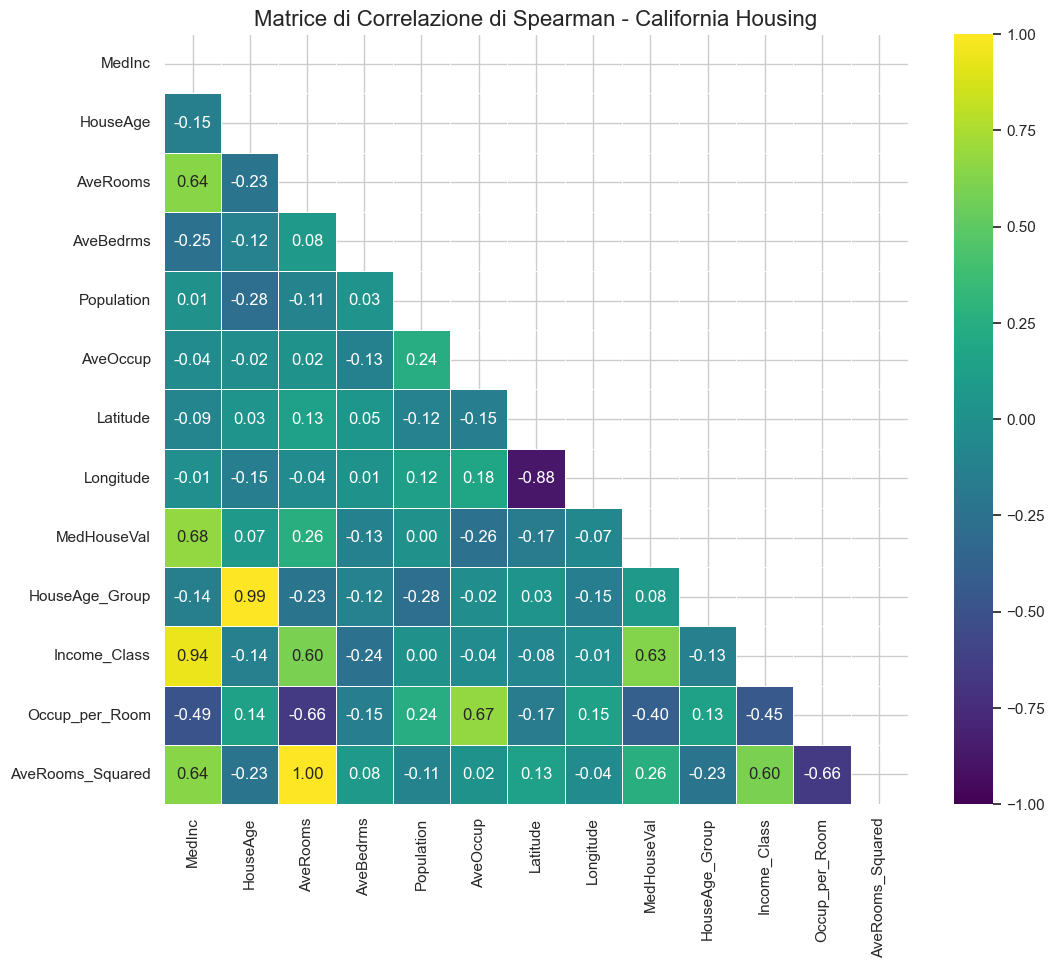

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcolo della matrice di Spearman
# Basta cambiare il parametro 'method'
corr_spearman = df.corr(method='spearman')

# 2. Creazione della maschera (per pulizia visiva)
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

# 3. Visualizzazione
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_spearman, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='viridis',    # Cambio colore per distinguerla dalla Pearson
    vmin=-1, vmax=1, 
    center=0,
    linewidths=.5
)

plt.title('Matrice di Correlazione di Spearman - California Housing', fontsize=16)
plt.show()

## Normalizzazione

Dobbiamo normalizzare i nostri dati per evitare che valori enormi come 5mln per i prezzi vadano ad annientare valori più piccoli come il numero di stanze delle case

Se devo minimizzare un errore e cambiando due valori ottendo

- un errore più basso di 2 punti sul numero di stanze (media 5.5)
- un errore più basso di 1000 euro sul valore di una casa (2 mln)

Il miglior miglioramento, con un approccio relativo è quello sul numero di stanze, ma matematicamente parlando 1000 è meglio di 2, dobbiamo evitare questa confusione ai nostri modelli

### 1. MinMaxScaler (Normalizzazione)

Trasforma i dati in un intervallo fisso, solitamente **[0, 1]**.


$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

* **Pro:** Mantiene esattamente la relazione tra i dati.
* **Contro:** È **estremamente sensibile agli outlier**. Se hai un solo valore enorme (es. una casa con 100 stanze), schiaccerà tutti gli altri valori vicini allo zero.

### 2. StandardScaler (Standardizzazione)

Trasforma i dati in modo che abbiano **Media = 0** e **Deviazione Standard = 1**.


$$z = \frac{x - \mu}{\sigma}$$

* **Pro:** È più robusto in presenza di outlier rispetto al Min-Max e rende i coefficienti dei modelli lineari più facili da interpretare.
* **Contro:** Non garantisce un range fisso (i valori possono andare oltre -3 o +3).

Tranne rare eccezioni di base si usa sempre lo standardScaler

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.datasets import fetch_california_housing

# 1. Prepariamo i dati
data = fetch_california_housing(as_frame=True)
X = data.frame[['MedInc', 'HouseAge', 'Population']] # Prendiamo 3 variabili con scale diverse

# 2. Inizializziamo gli Scaler
min_max = MinMaxScaler()
standard = StandardScaler()

# 3. Trasformazione
X_minmax = min_max.fit_transform(X)
X_standard = standard.fit_transform(X)

# Creiamo un DataFrame per confrontare i risultati sulla prima riga
comparison = pd.DataFrame({
    'Originale': X.iloc[0],
    'Min-Max [0, 1]': X_minmax[0],
    'Standard (z-score)': X_standard[0]
})

print("Confronto Scaler sulla prima riga del dataset:")
print(comparison)

Confronto Scaler sulla prima riga del dataset:
            Originale  Min-Max [0, 1]  Standard (z-score)
MedInc         8.3252        0.539668            2.344766
HouseAge      41.0000        0.784314            0.982143
Population   322.0000        0.008941           -0.974429


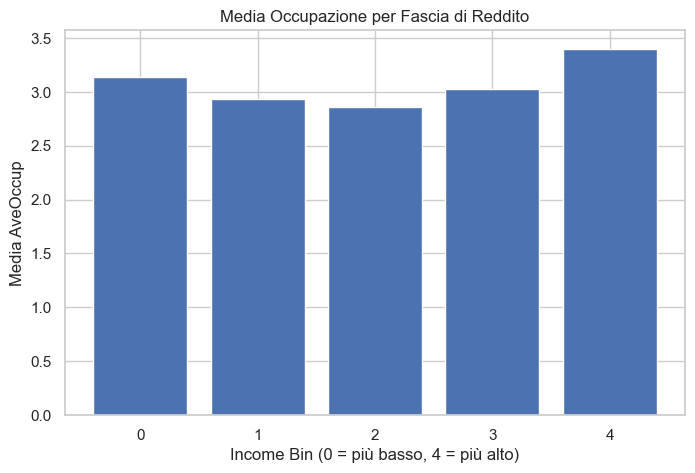

In [ ]:
df["Income_bin"] = pd.qcut(df["MedInc"], q=5, labels=False)

result = (
    df.groupby("Income_bin")["AveOccup"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
plt.bar(result["Income_bin"], result["AveOccup"])
plt.xlabel("Income Bin (0 = più basso, 4 = più alto)")
plt.ylabel("Media AveOccup")
plt.title("Media Occupazione per Fascia di Reddito")
plt.xticks(result["Income_bin"])
plt.show()

Dist_SF_bin
(-0.355, 90.776]      2.648716
(90.776, 181.005]     1.454303
(181.005, 271.234]    1.023350
(271.234, 361.462]    1.059002
(361.462, 451.691]    1.507836
(451.691, 541.92]     2.411970
(541.92, 632.149]     2.256794
(632.149, 722.378]    2.113426
(722.378, 812.606]    1.741506
(812.606, 902.835]    0.793266
Name: MedHouseVal, dtype: float64


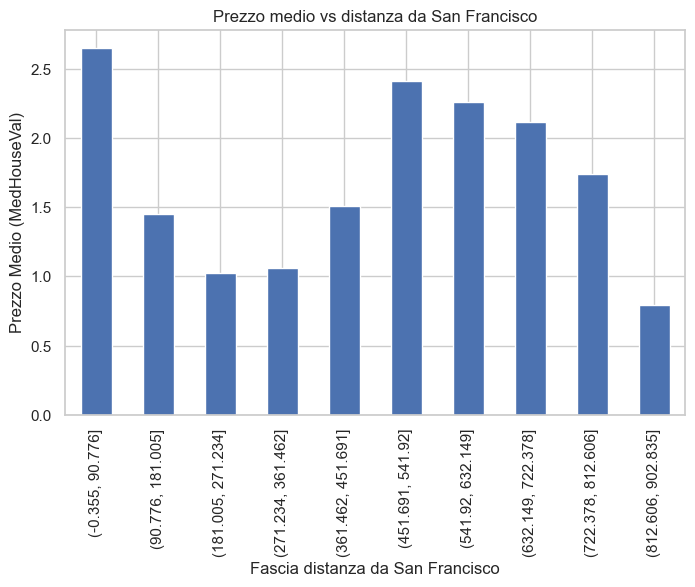

In [ ]:
#coordinate città
SF_lat, SF_lon = 37.7749, -122.4194
LA_lat, LA_lon = 34.0522, -118.2437

#Funzione Haversine (distanza in km),
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # raggio Terra in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

#Calcoliamo distanza da SF e LA,
df["Dist_SF"] = haversine(df["Latitude"], df["Longitude"], SF_lat, SF_lon)
df["Dist_LA"] = haversine(df["Latitude"], df["Longitude"], LA_lat, LA_lon)

#Binning distanza da SF (ogni 50 km),
df["Dist_SF_bin"] = pd.cut(df["Dist_SF"], bins=10)

#Prezzo medio per fascia di distanza,
price_by_distance = df.groupby("Dist_SF_bin")["MedHouseVal"].mean()

print(price_by_distance)

#Grafico,
plt.figure(figsize=(8,5))
price_by_distance.plot(kind="bar")
plt.ylabel("Prezzo Medio (MedHouseVal)")
plt.xlabel("Fascia distanza da San Francisco")
plt.title("Prezzo medio vs distanza da San Francisco")
plt.show()


In [ ]:
# Creiamo la colonna prendendo il valore minimo tra le due distanze calcolate prima
df["Dist_Min_City"] = df[["Dist_SF", "Dist_LA"]].min(axis=1)

print(df[["Dist_SF", "Dist_LA", "Dist_Min_City"]].head())

     Dist_SF     Dist_LA  Dist_Min_City
0  20.329542  556.531199      20.329542
1  19.908065  554.281885      19.908065
2  17.835390  554.612739      17.835390
3  17.064123  555.196283      17.064123
4  17.064123  555.196283      17.064123


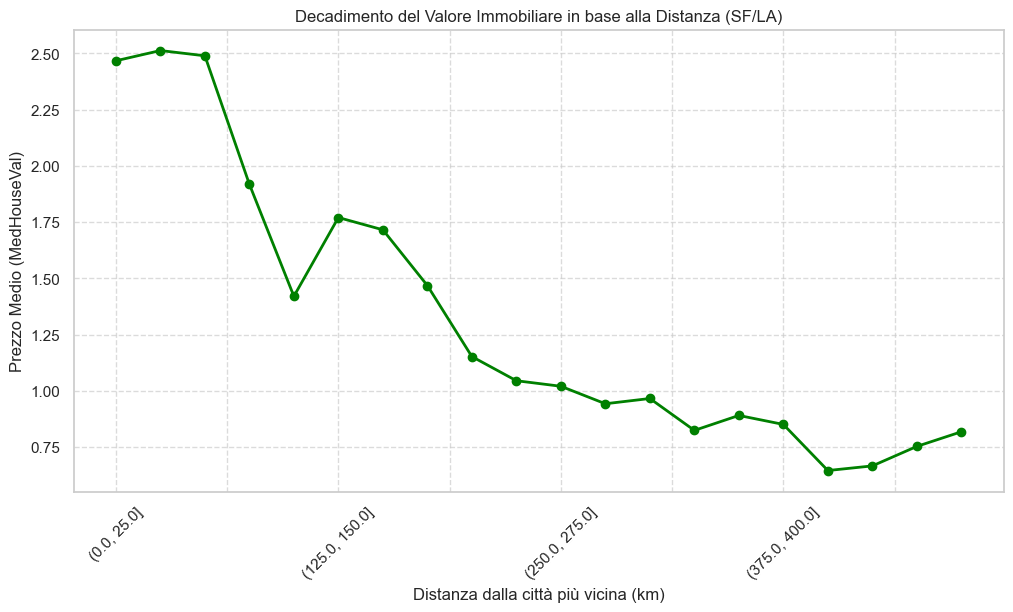

In [ ]:
# Creiamo i bin (fasce da 25km per maggiore precisione)
bins = np.arange(0, df["Dist_Min_City"].max() + 25, 25)
df["Dist_Min_bin"] = pd.cut(df["Dist_Min_City"], bins=bins)

# Calcoliamo il prezzo medio per ogni fascia
price_by_min_dist = df.groupby("Dist_Min_bin", observed=False)["MedHouseVal"].mean()

#Spiegazione: Riducendo la dimensione dei bin (da 50 a 25km), 
#otteniamo una granularità maggiore che ci permette di vedere meglio il crollo del prezzo appena si esce dai confini cittadini.

plt.figure(figsize=(12, 6))
price_by_min_dist.plot(kind="line", marker="o", color="green", linewidth=2)

plt.xticks(rotation=45)
plt.ylabel("Prezzo Medio (MedHouseVal)")
plt.xlabel("Distanza dalla città più vicina (km)")
plt.title("Decadimento del Valore Immobiliare in base alla Distanza (SF/LA)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calcoliamo l'occupazione media per ogni fascia di distanza
occupancy_by_distance = df.groupby("Dist_Min_bin", observed=False)["AveOccup"].mean()

print(occupancy_by_distance)

Dist_Min_bin
(0.0, 25.0]       2.978333
(25.0, 50.0]      3.000756
(50.0, 75.0]      3.492882
(75.0, 100.0]     3.024526
(100.0, 125.0]    2.950243
(125.0, 150.0]    2.773970
(150.0, 175.0]    2.954675
(175.0, 200.0]    2.889563
(200.0, 225.0]    3.002696
(225.0, 250.0]    2.884681
(250.0, 275.0]    3.621644
(275.0, 300.0]    3.223043
(300.0, 325.0]    2.718877
(325.0, 350.0]    9.989090
(350.0, 375.0]    2.568874
(375.0, 400.0]    2.599016
(400.0, 425.0]    2.570452
(425.0, 450.0]    2.581575
(450.0, 475.0]    2.835470
(475.0, 500.0]    2.611499
Name: AveOccup, dtype: float64


C:\Users\Davec\AppData\Local\Temp\ipykernel_1336\3099128897.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occupancy_by_distance.index.astype(str),


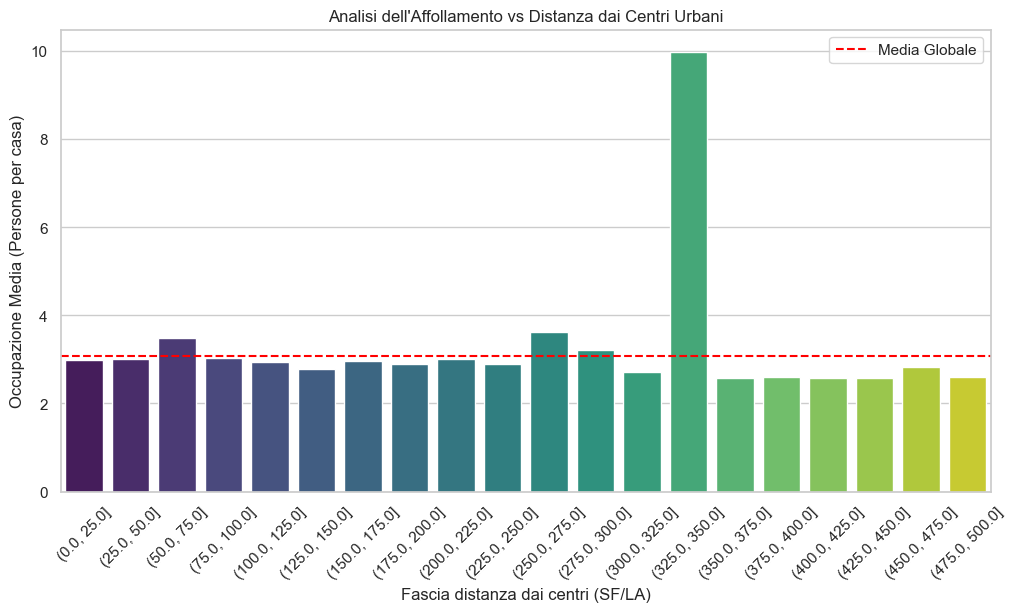

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 6))

# Creiamo il grafico a barre
sns.barplot(x=occupancy_by_distance.index.astype(str), 
            y=occupancy_by_distance.values, 
            palette="viridis")

plt.xticks(rotation=45)
plt.ylabel("Occupazione Media (Persone per casa)")
plt.xlabel("Fascia distanza dai centri (SF/LA)")
plt.title("Analisi dell'Affollamento vs Distanza dai Centri Urbani")

# Aggiungiamo una linea orizzontale per la media globale
plt.axhline(df['AveOccup'].mean(), color='red', linestyle='--', label='Media Globale')
plt.legend()
plt.show()

In [ ]:
# Controlliamo quanti dati ci sono in quel bin specifico
conteggio_bin = df[df['Dist_Min_bin'].astype(str) == '(325.0, 350.0]'].shape[0]
print(f"Numero di osservazioni nel bin incriminato: {conteggio_bin}")

Numero di osservazioni nel bin incriminato: 81


In [ ]:
# Isoliamo i record di quel bin
bin_anomalo = df[df['Dist_Min_bin'].astype(str) == '(325.0, 350.0]']

# Ordiniamo per AveOccup per trovare il colpevole
print(bin_anomalo[['AveOccup', 'MedInc', 'Population', 'Latitude', 'Longitude']].sort_values(by='AveOccup', ascending=False).head())

"""3. Effetto "Deserto o Confine"

Geograficamente, 325-350 km dai centri principali della California (SF/LA) ti porta in zone molto isolate: 
verso il deserto del Mojave o l'estremo nord ai confini con l'Oregon.
Ipotesi Sociale: In queste zone remote, le strutture abitative potrebbero essere diverse 
(es. dormitori per lavoratori stagionali o grandi comunità rurali), portando a un AveOccup reale più alto della media urbana.
Ipotesi Tecnica: È un'area dove il dataset è "scarso". 
I pochi punti presenti non riescono a bilanciarsi e creano quel picco che rompe visivamente il trend."""

         AveOccup  MedInc  Population  Latitude  Longitude
3364   599.714286  5.5179      4198.0     40.41    -120.51
12455    4.607438  2.1759      1115.0     33.62    -114.61
12449    3.745875  1.6395      1135.0     33.49    -114.68
18801    3.697674  3.1500       477.0     40.69    -121.83
2651     3.641509  3.5345       965.0     40.47    -124.10


'3. Effetto "Deserto o Confine"\n\nGeograficamente, 325-350 km dai centri principali della California (SF/LA) ti porta in zone molto isolate: \nverso il deserto del Mojave o l\'estremo nord ai confini con l\'Oregon.\nIpotesi Sociale: In queste zone remote, le strutture abitative potrebbero essere diverse \n(es. dormitori per lavoratori stagionali o grandi comunità rurali), portando a un AveOccup reale più alto della media urbana.\nIpotesi Tecnica: È un\'area dove il dataset è "scarso". \nI pochi punti presenti non riescono a bilanciarsi e creano quel picco che rompe visivamente il trend.'

In [ ]:
# Filtriamo AveOccup per mantenere solo valori ragionevoli (es. < 10)
df_clean = df[df['AveOccup'] < 10].copy()

# Ricalcoliamo le medie per bin sul dataset pulito
stats_clean = df_clean.groupby("Dist_Min_bin", observed=False)[["MedHouseVal", "AveOccup"]].mean()

print(f"Righe rimosse con il filtro: {len(df) - len(df_clean)}")

Righe rimosse con il filtro: 37


Perfetto, applichiamo un filtro di "pulizia" per rimuovere i valori fisicamente o statisticamente improbabili di AveOccup. In dataset come quello della California Housing, valori superiori a 10 (persone medie per casa in un intero isolato) sono quasi sempre errori di campionamento o situazioni estremamente specifiche che distorcono il trend generale.

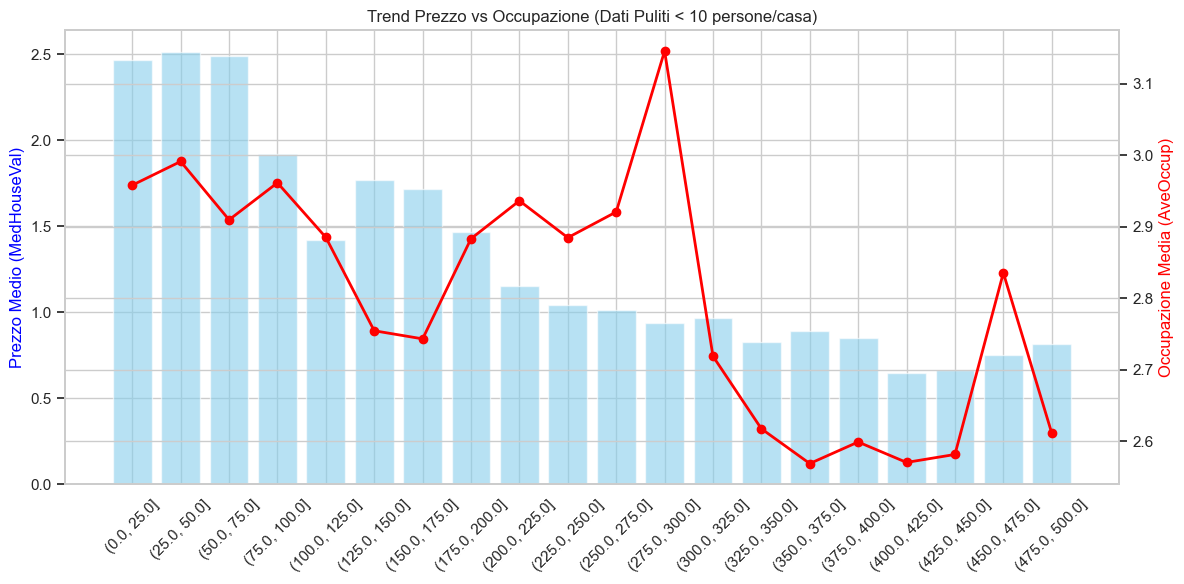

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Prezzo Medio (Barre)
ax1.bar(stats_clean.index.astype(str), stats_clean['MedHouseVal'], color='skyblue', alpha=0.6, label='Prezzo')
ax1.set_ylabel('Prezzo Medio (MedHouseVal)', color='blue')
plt.xticks(rotation=45)

# Occupazione Media (Linea) - Ora molto più stabile
ax2 = ax1.twinx()
ax2.plot(stats_clean.index.astype(str), stats_clean['AveOccup'], color='red', marker='o', linewidth=2, label='AveOccup')
ax2.set_ylabel('Occupazione Media (AveOccup)', color='red')

plt.title('Trend Prezzo vs Occupazione (Dati Puliti < 10 persone/casa)')
fig.tight_layout()
plt.show()

In [ ]:
# Confronto diretto del bin specifico prima e dopo (concettuale)
valore_nuovo = stats_clean.loc[stats_clean.index.astype(str) == '(325.0, 350.0]', 'AveOccup'].values[0]
print(f"Nuova occupazione media nel bin (325, 350]: {valore_nuovo:.2f}")

Nuova occupazione media nel bin (325, 350]: 2.62


In [ ]:
# Creiamo i gruppi: 'Basso' per il primo 50%, 'Alto' per il secondo 50%
df_clean['Income_Group'] = pd.qcut(df_clean['MedInc'], q=2, labels=['Reddito Basso', 'Reddito Alto'])

# Verifichiamo che i gruppi siano bilanciati
print(df_clean['Income_Group'].value_counts())

"""Gemini ha detto
Il metodo qcut di pandas è fondamentale per la discretizzazione dei dati. 
Serve a suddividere una variabile numerica continua in "bin" (intervalli o gruppi) basati sui quantili (percentili), 
garantendo che ogni gruppo contenga approssimativamente lo stesso numero di osservazioni."""

Income_Group
Reddito Basso    10302
Reddito Alto     10301
Name: count, dtype: int64


In [ ]:
# Raggruppiamo per distanza e fascia di reddito
comparison_stats = df_clean.groupby(['Dist_Min_bin', 'Income_Group'], observed=False)['AveOccup'].mean().unstack()

# --- SOLUZIONE KEYERROR ---
# Convertiamo l'indice (che è un IntervalIndex) in stringhe
comparison_stats.index = comparison_stats.index.astype(str)

# Ora puoi stampare il bin specifico senza errori
print("Dati estratti per il bin critico:")
print(comparison_stats.loc[['(325.0, 350.0]']])

Dati estratti per il bin critico:
Income_Group    Reddito Basso  Reddito Alto
Dist_Min_bin                               
(325.0, 350.0]       2.618565       2.57697


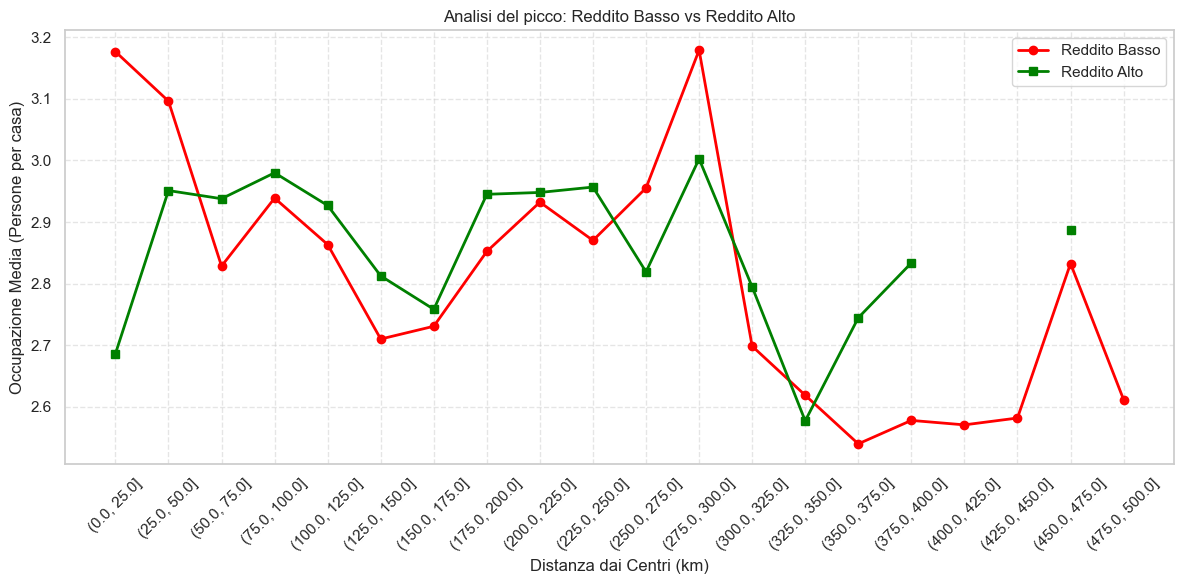

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Disegniamo le due linee
plt.plot(comparison_stats.index, comparison_stats['Reddito Basso'], 
         marker='o', color='red', label='Reddito Basso', linewidth=2)
plt.plot(comparison_stats.index, comparison_stats['Reddito Alto'], 
         marker='s', color='green', label='Reddito Alto', linewidth=2)

plt.xticks(rotation=45)
plt.ylabel("Occupazione Media (Persone per casa)")
plt.xlabel("Distanza dai Centri (km)")
plt.title("Analisi del picco: Reddito Basso vs Reddito Alto")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. La Disuguaglianza Geografica

Il confronto tra le due linee (Reddito Alto vs Reddito Basso) rivela che l'occupazione delle case non dipende solo dalla distanza, ma da come il reddito interagisce con essa.

    Fascia Reddito Alto (Linea Verde): Rimane estremamente stabile. Chi ha disponibilità economica tende a mantenere un'occupazione media costante (circa 2.5 - 2.8 persone per casa), indipendentemente da quanto sia lontano da San Francisco o Los Angeles.

    Fascia Reddito Basso (Linea Rossa): Mostra una variabilità enorme. È proprio questa linea a generare il "picco" nel bin (325-350km).

2. L'Interpretazione del Picco (325-350 km)

In quella specifica fascia di distanza, la linea del reddito basso svetta sopra quella del reddito alto. Questo ci dice che:

    Non è un fattore strutturale: Se fosse un problema di "case grandi costruite in periferia", vedremmo salire anche la linea verde.

    È un fattore di disagio: Nelle zone remote (come la Central Valley profonda o le aree montuose/desertiche), il basso reddito costringe a una densità abitativa più alta. In queste aree, le famiglie sono più numerose o, più probabilmente, più persone condividono lo stesso alloggio per abbattere i costi in zone dove l'economia è debole.

In [ ]:
# Calcoliamo lo scarto tra i due gruppi nel bin incriminato
diff = comparison_stats.loc['(325.0, 350.0]', 'Reddito Basso'] - comparison_stats.loc['(325.0, 350.0]', 'Reddito Alto']
print(f"Differenza di affollamento nel bin critico: {diff:.2f} persone/casa")

Differenza di affollamento nel bin critico: 0.04 persone/casa


Noterai che nei bin vicini alle città (0-100km), le due linee sono più vicine. Man mano che ci si allontana, la forbice si allarga.

Spiegazione: Questo valore numerico quantifica il "sovrapprezzo sociale" della distanza per chi ha un reddito basso. Mentre i ricchi "comprano" spazio, i poveri in periferia sono costretti a "stringersi".

# Sintesi Finale

Abbiamo trasformato un dubbio su un "valore anomalo" in una scoperta statistica: il sovraffollamento in California è un fenomeno che esplode nelle zone rurali/isolate solo per le fasce di reddito più basse. Senza questa divisione in bin di reddito, avremmo pensato a un semplice errore dei dati; ora sappiamo che è una caratteristica del tessuto sociale californiano.

Se dividete il reddito in 10 gruppi (decili), il prezzo delle case sale sempre della stessa quantità tra un gruppo e l'altro? O c'è un punto in cui, anche se il reddito raddoppia, il prezzo della casa smette di salire drasticamente?

In [ ]:
# Creiamo 10 gruppi di reddito (decili)
df['Income_Decile'] = pd.qcut(df['MedInc'], q=10, labels=[f'D{i+1}' for i in range(10)])

# Calcoliamo il prezzo medio e il reddito medio per ogni decile
decile_stats = df.groupby('Income_Decile', observed=False)[['MedInc', 'MedHouseVal']].mean()

print(decile_stats)

                 MedInc  MedHouseVal
Income_Decile                       
D1             1.515145     1.101797
D2             2.139838     1.266338
D3             2.557075     1.477231
D4             2.955537     1.663145
D5             3.326199     1.862524
D6             3.732804     2.015082
D7             4.182009     2.207469
D8             4.763660     2.393294
D9             5.577262     2.799943
D10            7.959844     3.899877


In [ ]:
# Calcoliamo la differenza di prezzo rispetto al decile precedente
decile_stats['Price_Increase'] = decile_stats['MedHouseVal'].diff()

print(decile_stats)

                 MedInc  MedHouseVal  Price_Increase
Income_Decile                                       
D1             1.515145     1.101797             NaN
D2             2.139838     1.266338        0.164541
D3             2.557075     1.477231        0.210894
D4             2.955537     1.663145        0.185913
D5             3.326199     1.862524        0.199380
D6             3.732804     2.015082        0.152557
D7             4.182009     2.207469        0.192387
D8             4.763660     2.393294        0.185825
D9             5.577262     2.799943        0.406650
D10            7.959844     3.899877        1.099933


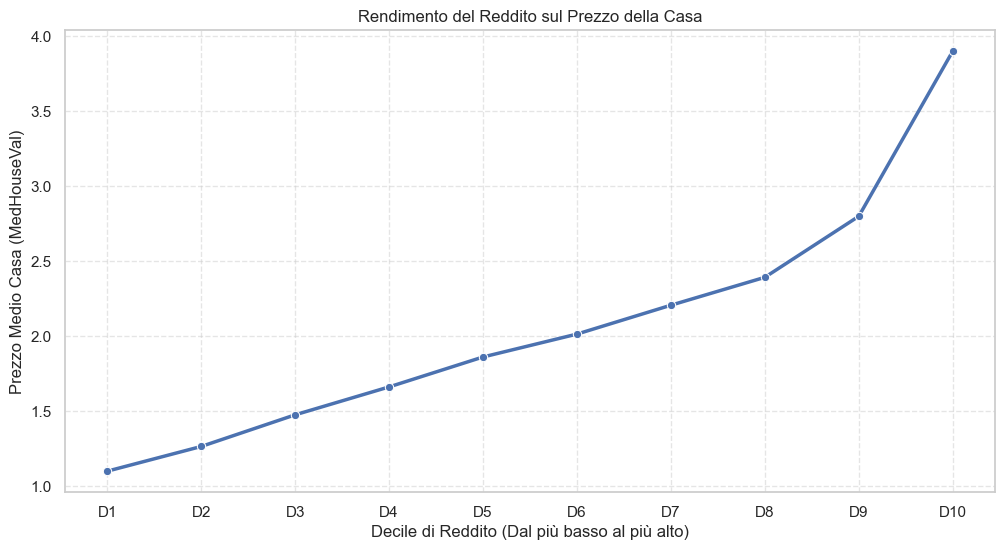

In [ ]:
plt.figure(figsize=(12, 6))

# Grafico della relazione
sns.lineplot(data=decile_stats, x=decile_stats.index, y='MedHouseVal', marker='o', linewidth=2.5)

plt.ylabel("Prezzo Medio Casa (MedHouseVal)")
plt.xlabel("Decile di Reddito (Dal più basso al più alto)")
plt.title("Rendimento del Reddito sul Prezzo della Casa")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
 # 1️⃣ Creiamo i decili
df["Income_decile"] = pd.qcut(df["MedInc"], q=10, labels=False)

# 2️⃣ Calcoliamo statistiche per decile
deciles = (
    df.groupby("Income_decile")
      .agg(mean_income=("MedInc", "mean"),
           mean_price=("MedHouseVal", "mean"))
      .reset_index()
)

# 3️⃣ Incremento tra decili
deciles["price_increment"] = deciles["mean_price"].diff()

print(deciles)

# -----------------------------

   Income_decile  mean_income  mean_price  price_increment
0              0     1.515145    1.101797              NaN
1              1     2.139838    1.266338         0.164541
2              2     2.557075    1.477231         0.210894
3              3     2.955537    1.663145         0.185913
4              4     3.326199    1.862524         0.199380
5              5     3.732804    2.015082         0.152557
6              6     4.182009    2.207469         0.192387
7              7     4.763660    2.393294         0.185825
8              8     5.577262    2.799943         0.406650
9              9     7.959844    3.899877         1.099933


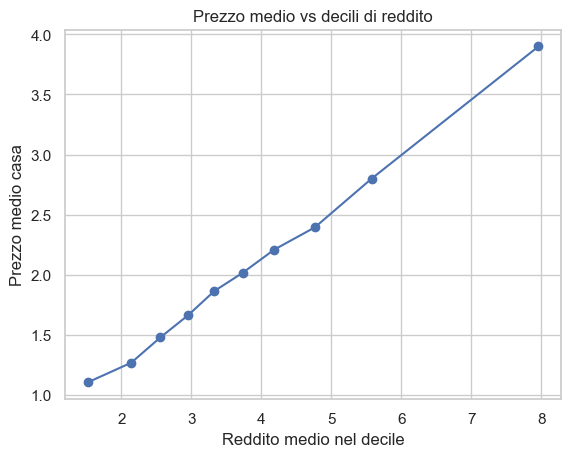

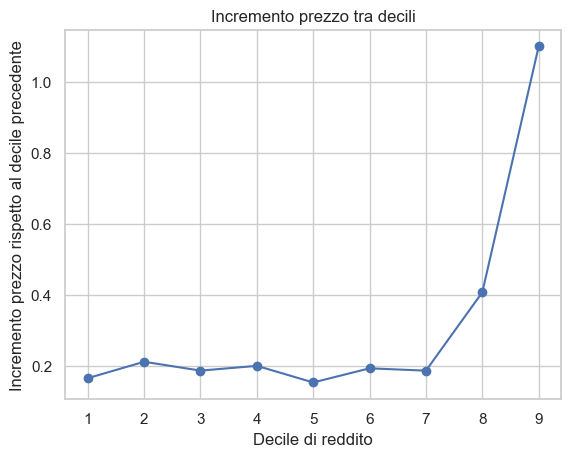

In [ ]:
# Grafico 1: curva reddito-prezzo
# -----------------------------
plt.figure()
plt.plot(deciles["mean_income"], deciles["mean_price"], marker='o')
plt.xlabel("Reddito medio nel decile")
plt.ylabel("Prezzo medio casa")
plt.title("Prezzo medio vs decili di reddito")
plt.show()

# -----------------------------
# Grafico 2: incremento tra decili
# -----------------------------
plt.figure()
plt.plot(deciles["Income_decile"], deciles["price_increment"], marker='o')
plt.xlabel("Decile di reddito")
plt.ylabel("Incremento prezzo rispetto al decile precedente")
plt.title("Incremento prezzo tra decili")
plt.show()  

        Age_bin   mean_age  mean_price
0  (0.949, 6.1]   4.520167    2.162053
1   (6.1, 11.2]   9.195652    1.851975
2  (11.2, 16.3]  14.570917    1.907387
3  (16.3, 21.4]  18.772846    1.941120
4  (21.4, 26.5]  24.222311    2.104373
5  (26.5, 31.6]  28.976636    2.042390
6  (31.6, 36.7]  34.225879    2.075264
7  (36.7, 41.8]  38.698947    2.034777
8  (41.8, 46.9]  43.811262    2.052642
9  (46.9, 52.0]  50.769074    2.532209


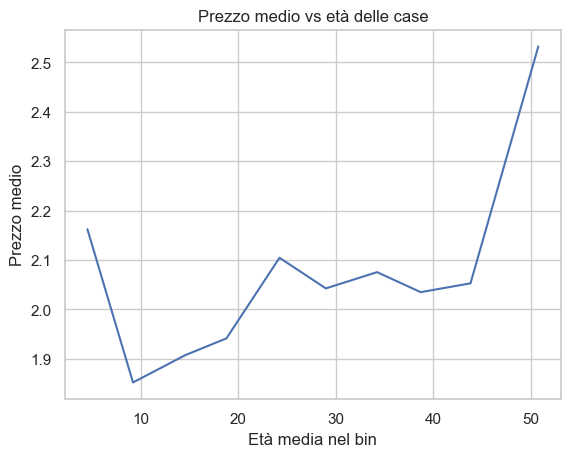

In [ ]:
# Creiamo 10 bin di età
df["Age_bin"] = pd.cut(df["HouseAge"], bins=10)

# Prezzo medio per bin
age_stats = (
    df.groupby("Age_bin")
      .agg(mean_age=("HouseAge", "mean"),
           mean_price=("MedHouseVal", "mean"))
      .reset_index()
)

print(age_stats)

# Grafico
plt.figure()
plt.plot(age_stats[
"mean_age"], age_stats["mean_price"])
plt.xlabel("Età media nel bin")
plt.ylabel("Prezzo medio")
plt.title("Prezzo medio vs età delle case")
plt.show() 

Il "Perché": Questo accade spesso nei dataset immobiliari a causa della posizione. Le case molto vecchie sono state costruite nei centri urbani consolidati o in zone costiere pregiate. Le case di media età potrebbero trovarsi in zone suburbane meno costose.

Contestualizzazione:
Il grafico a barre mostra chiaramente un picco di valore per le case più datate. Questo suggerisce che HouseAge non è un semplice indicatore di deprezzamento, ma agisce spesso come proxy per la posizione geografica (le zone vecchie sono zone storiche/centrali).

In [ ]:
# Selezioniamo le colonne di interesse
columns_to_correlate = ["Latitude", "Longitude", "MedHouseVal"]

# Calcoliamo la matrice di correlazione
correlation_matrix = df[columns_to_correlate].corr()

print(correlation_matrix)

             Latitude  Longitude  MedHouseVal
Latitude     1.000000  -0.924664    -0.144160
Longitude   -0.924664   1.000000    -0.045967
MedHouseVal -0.144160  -0.045967     1.000000


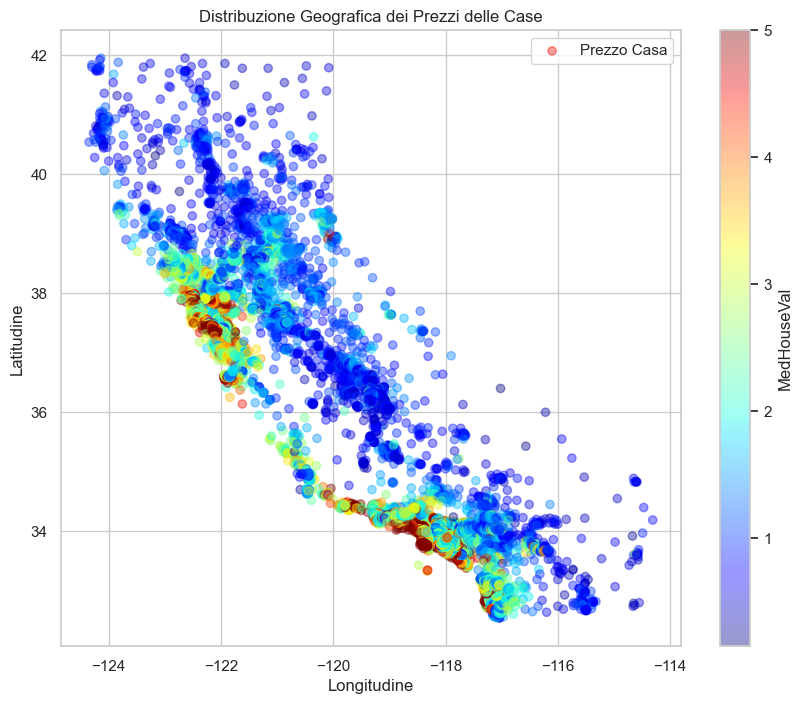

In [ ]:
# Grafico di dispersione geografico
plt.figure(figsize=(10, 8))
plt.scatter(df["Longitude"], df["Latitude"], 
            alpha=0.4, c=df["MedHouseVal"], 
            cmap="jet", label="Prezzo Casa")
plt.colorbar(label="MedHouseVal")
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.title("Distribuzione Geografica dei Prezzi delle Case")
plt.legend()
plt.show()

In [ ]:
 
# :one: Creiamo bin per AveOccup
df["Occup_bin"] = pd.cut(df["AveOccup"], bins=[0, 1, 2, 3, 4, 5, 10, 20, 50])

# :two: Prezzo medio per bin
occup_stats = (
    df.groupby("Occup_bin")
      .agg(
          mean_occup=("AveOccup", "mean"),
          mean_price=("MedHouseVal", "mean"),
          count=("MedHouseVal", "count")
      )
      .reset_index()
)

print(occup_stats)

  Occup_bin  mean_occup  mean_price  count
0    (0, 1]    0.804299    2.068333      3
1    (1, 2]    1.773924    2.699382   1648
2    (2, 3]    2.566185    2.216428  11001
3    (3, 4]    3.373242    1.817084   6247
4    (4, 5]    4.376182    1.404900   1396
5   (5, 10]    5.818116    1.550451    308
6  (10, 20]   13.985302    1.691557     27
7  (20, 50]   32.166853    2.986003      3


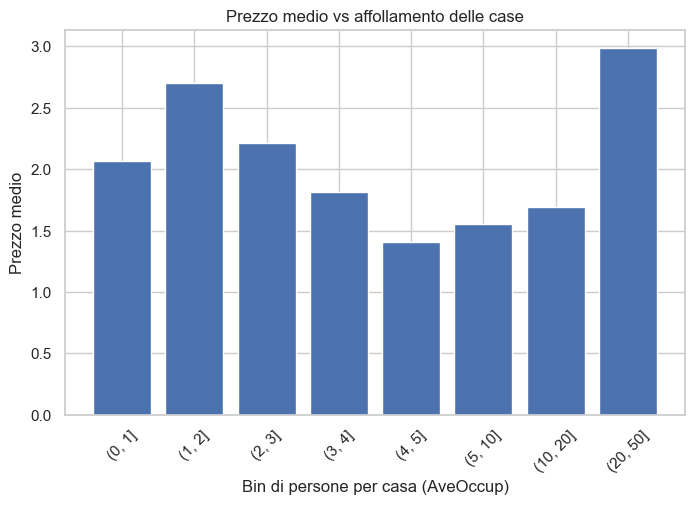

In [ ]:

# :three: Grafico prezzo medio per bin
plt.figure(figsize=(8,5))
plt.bar(occup_stats["Occup_bin"].astype(str), occup_stats["mean_price"])
plt.xticks(rotation=45)
plt.xlabel("Bin di persone per casa (AveOccup)")
plt.ylabel("Prezzo medio")
plt.title("Prezzo medio vs affollamento delle case")
plt.show() 